## Assignment No.17

 # Part 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("exchange_rate.csv", parse_dates=['date'], dayfirst=True)
df.columns = df.columns.str.strip()
df = df.rename(columns={'Ex_rate': 'AUD'})
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)
df = df.asfreq('D')
df['AUD'] = df['AUD'].ffill()

print("Shape:", df.shape)
print("Date Range:", df.index.min(), "→", df.index.max())
print("Frequency:", df.index.freq)
print("\nMissing Values:", df.isnull().sum().values[0])
print("\nFirst 5 Rows:\n", df.head())
print("\nBasic Statistics:\n", df.describe())

Shape: (7588, 1)
Date Range: 1990-01-01 00:00:00 → 2010-10-10 00:00:00
Frequency: <Day>

Missing Values: 0

First 5 Rows:
                AUD
date              
1990-01-01  0.7855
1990-01-02  0.7818
1990-01-03  0.7867
1990-01-04  0.7860
1990-01-05  0.7849

Basic Statistics:
                AUD
count  7588.000000
mean      0.776974
std       0.136620
min       0.483297
25%       0.701422
50%       0.761377
75%       0.873477
max       1.102536


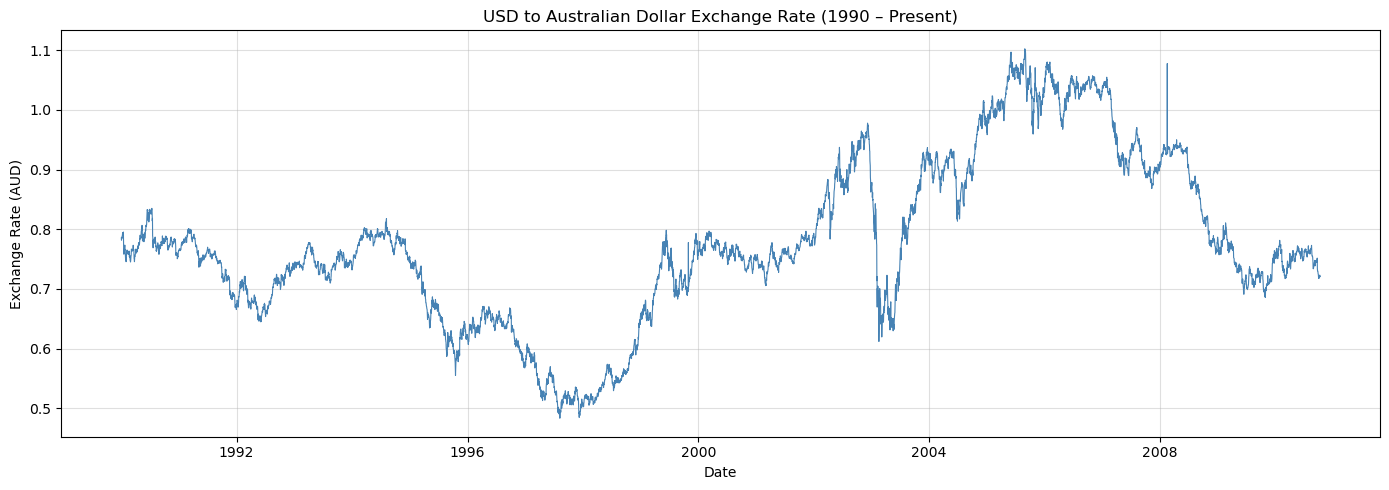

In [2]:
#Full Time Series Plot
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['AUD'], color='steelblue', linewidth=0.8)
plt.title('USD to Australian Dollar Exchange Rate (1990 – Present)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (AUD)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('full_timeseries.png')
plt.show()

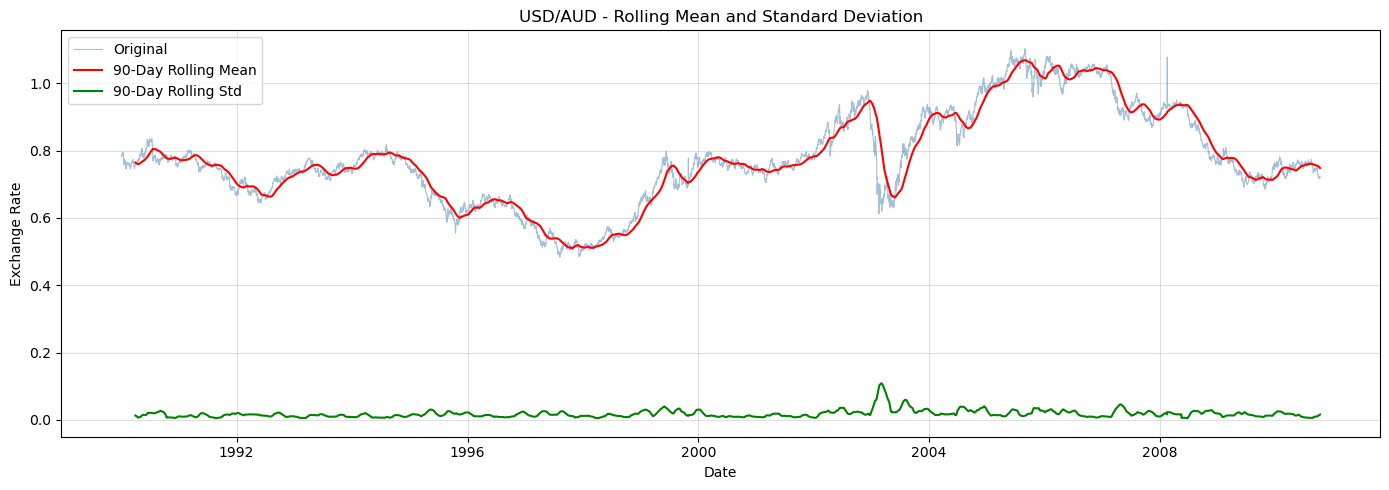

In [3]:
#Rolling Mean & Std (Trend + Volatility)
rolling_mean = df['AUD'].rolling(window=90).mean()
rolling_std  = df['AUD'].rolling(window=90).std()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['AUD'],    label='Original',            color='steelblue', alpha=0.5, linewidth=0.8)
plt.plot(df.index, rolling_mean, label='90-Day Rolling Mean', color='red',       linewidth=1.5)
plt.plot(df.index, rolling_std,  label='90-Day Rolling Std',  color='green',     linewidth=1.5)
plt.title('USD/AUD - Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('rolling_stats.png')
plt.show()

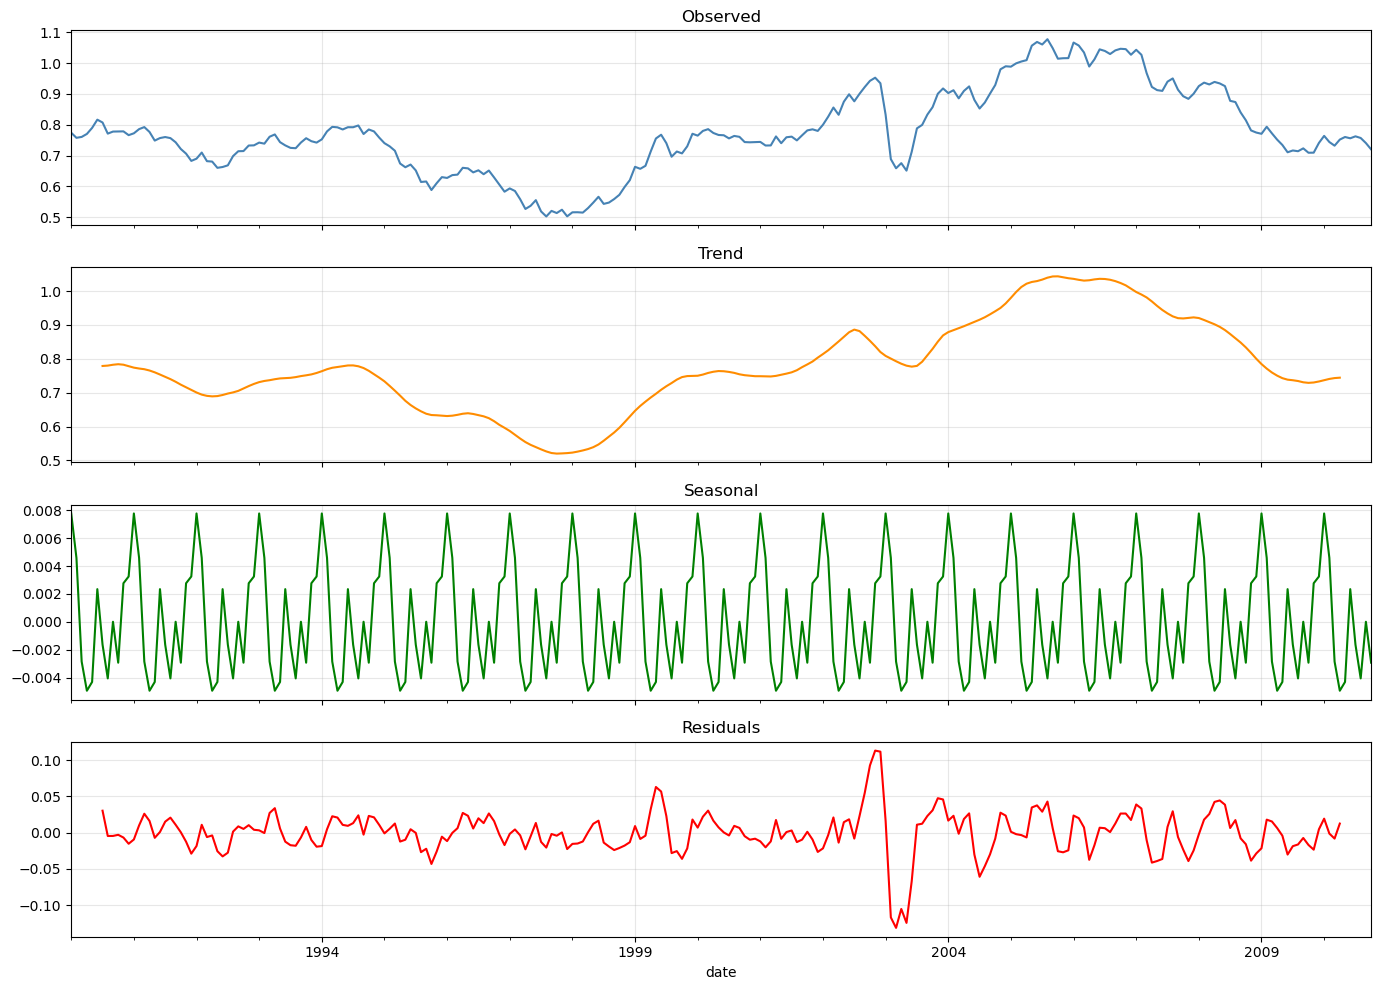

In [4]:
#Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

df_monthly = df['AUD'].resample('MS').mean()
decomposition = seasonal_decompose(df_monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed',  color='steelblue')
decomposition.trend.plot(ax=axes[1],    title='Trend',     color='darkorange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal',  color='green')
decomposition.resid.plot(ax=axes[3],    title='Residuals', color='red')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('seasonal_decomposition.png')
plt.show()

Missing values: 0
Anomalies detected (Z-score > 3): 0


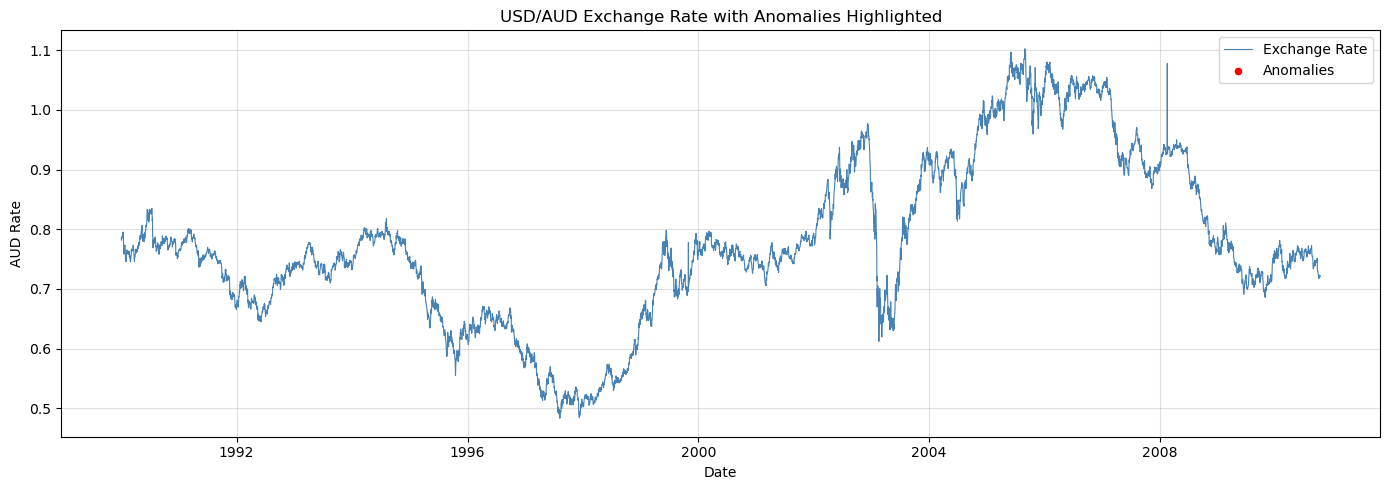

In [5]:
#Handle Missing Values & Anomalies
from scipy import stats

print("Missing values:", df.isnull().sum().values[0])
z_scores = np.abs(stats.zscore(df['AUD']))
anomalies = df[z_scores > 3]
print(f"Anomalies detected (Z-score > 3): {len(anomalies)}")

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['AUD'], color='steelblue', linewidth=0.8, label='Exchange Rate')
plt.scatter(anomalies.index, anomalies['AUD'], color='red', s=20, zorder=5, label='Anomalies')
plt.title('USD/AUD Exchange Rate with Anomalies Highlighted')
plt.xlabel('Date')
plt.ylabel('AUD Rate')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('anomalies.png')
plt.show()

# Part 2

In [6]:
#Stationarity Test (ADF Test)
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f"\nADF Test for: {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.6f}")
    for key, val in result[4].items():
        print(f"  Critical Value ({key}): {val:.4f}")
    if result[1] <= 0.05:
        print("  STATIONARY")
    else:
        print("  NON-STATIONARY")

adf_test(df['AUD'], 'Original AUD Rate')
df['AUD_diff'] = df['AUD'].diff()
adf_test(df['AUD_diff'].dropna(), '1st Differenced AUD Rate')


ADF Test for: Original AUD Rate
  ADF Statistic : -1.6650
  p-value       : 0.449233
  Critical Value (1%): -3.4312
  Critical Value (5%): -2.8619
  Critical Value (10%): -2.5670
  NON-STATIONARY

ADF Test for: 1st Differenced AUD Rate
  ADF Statistic : -99.3934
  p-value       : 0.000000
  Critical Value (1%): -3.4312
  Critical Value (5%): -2.8619
  Critical Value (10%): -2.5670
  STATIONARY


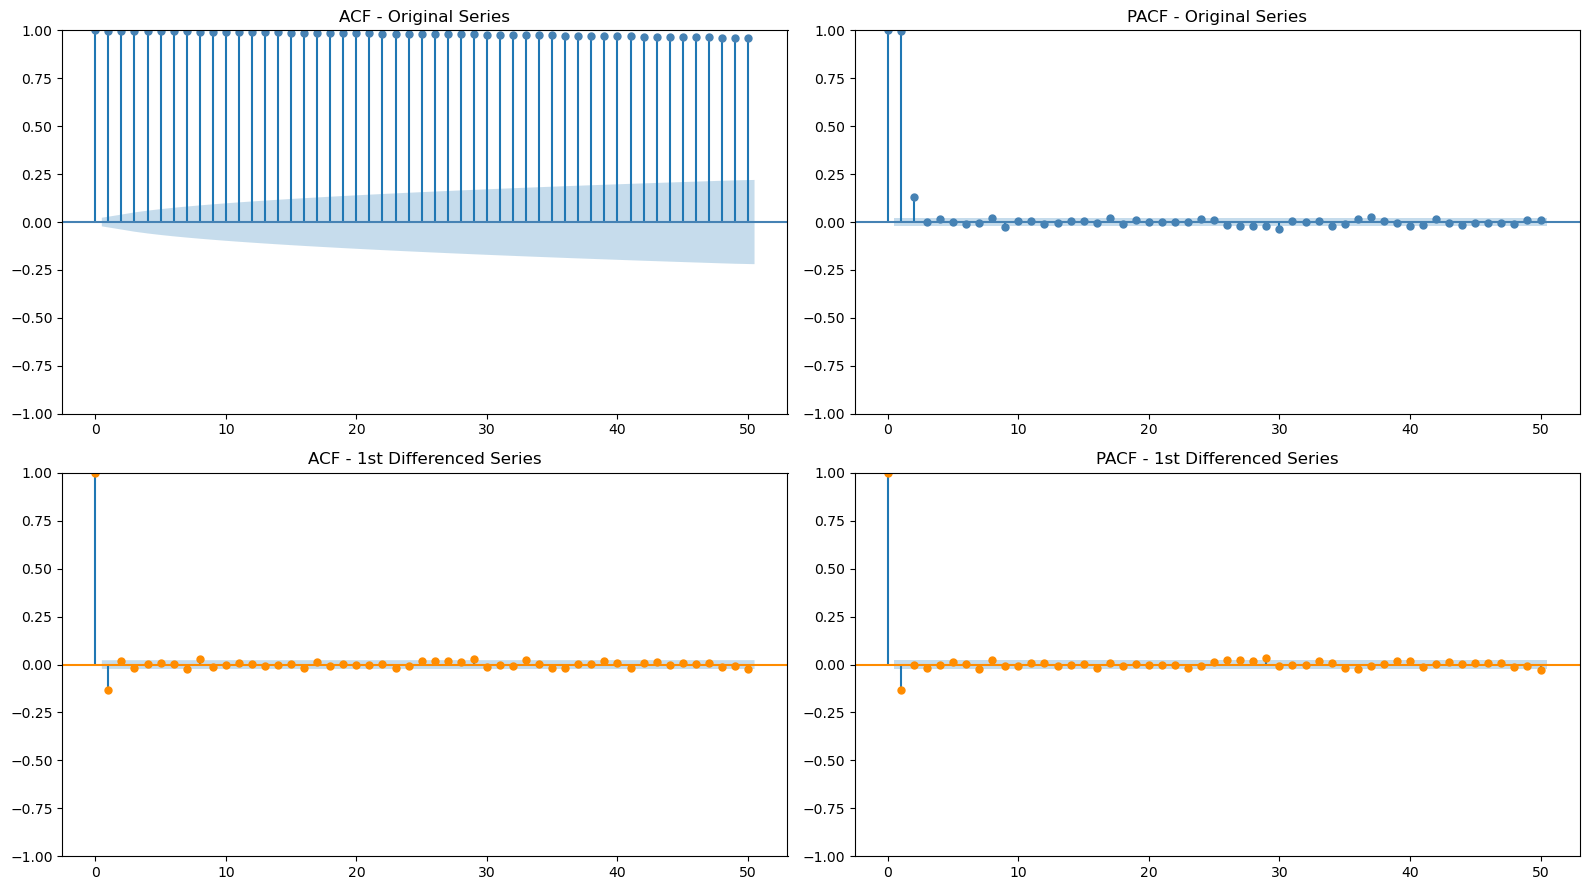

In [7]:
#ACF & PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

plot_acf(df['AUD'].dropna(),       lags=50, ax=axes[0, 0], title='ACF - Original Series',            color='steelblue')
plot_pacf(df['AUD'].dropna(),      lags=50, ax=axes[0, 1], title='PACF - Original Series',           color='steelblue')
plot_acf(df['AUD_diff'].dropna(),  lags=50, ax=axes[1, 0], title='ACF - 1st Differenced Series',     color='darkorange')
plot_pacf(df['AUD_diff'].dropna(), lags=50, ax=axes[1, 1], title='PACF - 1st Differenced Series',    color='darkorange')

plt.tight_layout()
plt.savefig('acf_pacf.png')
plt.show()

Train: 1990-01-01 → 2010-07-12 | 7498 records
Test : 2010-07-13 → 2010-10-10 | 90 records


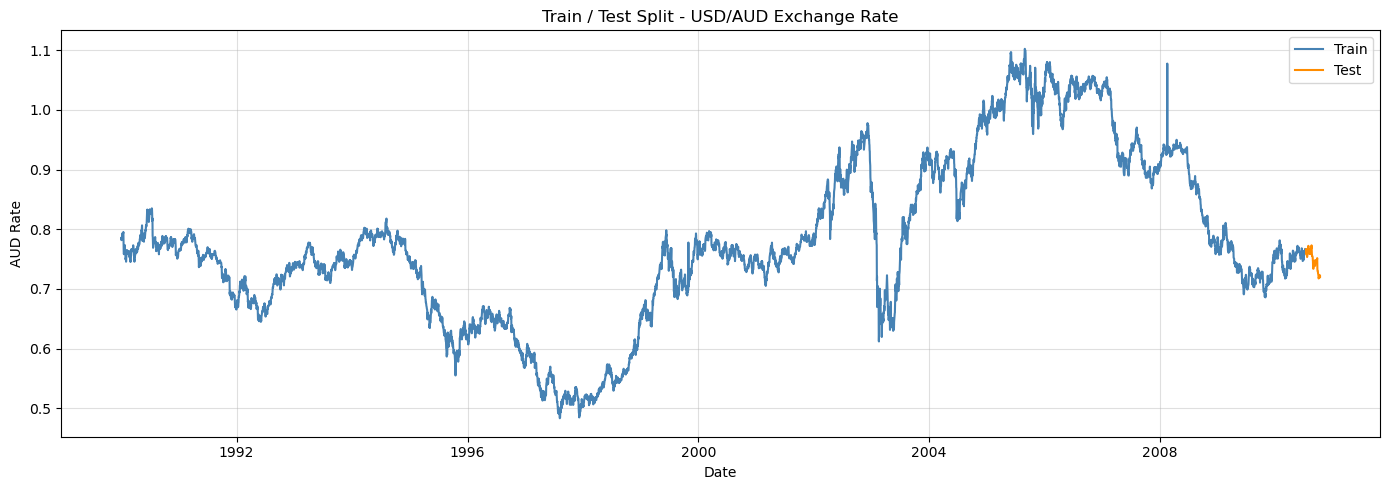

In [8]:
#Train-Test Split
test_size = 90
train = df['AUD'].iloc[:-test_size]
test  = df['AUD'].iloc[-test_size:]

print(f"Train: {train.index.min().date()} → {train.index.max().date()} | {len(train)} records")
print(f"Test : {test.index.min().date()} → {test.index.max().date()} | {len(test)} records")

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train', color='steelblue')
plt.plot(test.index,  test,  label='Test',  color='darkorange')
plt.title('Train / Test Split - USD/AUD Exchange Rate')
plt.xlabel('Date')
plt.ylabel('AUD Rate')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('train_test_split.png')
plt.show()

In [9]:
#ARIMA Model Fitting
from statsmodels.tsa.arima.model import ARIMA

train_arima  = train.asfreq('D').ffill()
arima_model  = ARIMA(train_arima, order=(1, 1, 1))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                    AUD   No. Observations:                 7498
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27694.404
Date:                Sat, 04 Apr 2026   AIC                         -55382.808
Time:                        18:54:41   BIC                         -55362.041
Sample:                    01-01-1990   HQIC                        -55375.677
                         - 07-12-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1275      0.045     -2.819      0.005      -0.216      -0.039
ma.L1         -0.0049      0.045     -0.109      0.913      -0.094       0.084
sigma2      3.622e-05   1.01e-07    359.020      0.0

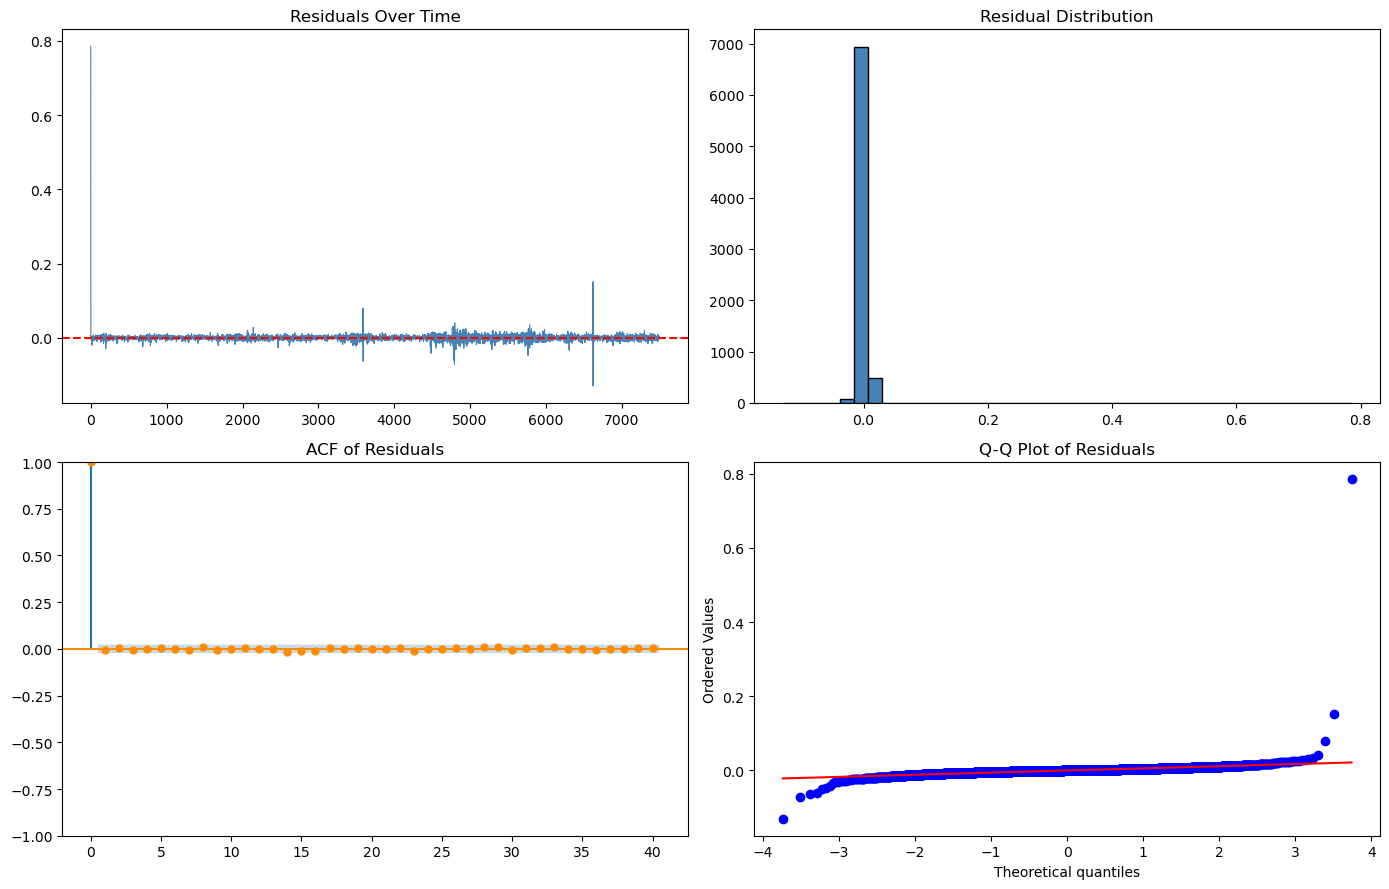

In [10]:
#ARIMA Diagnostics (Residual Analysis)
from scipy.stats import probplot

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
residuals = pd.Series(arima_result.resid)

axes[0, 0].plot(residuals.values, color='steelblue', linewidth=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals Over Time')

axes[0, 1].hist(residuals, bins=40, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Residual Distribution')

plot_acf(residuals.dropna(), lags=40, ax=axes[1, 0], title='ACF of Residuals', color='darkorange')

probplot(residuals.dropna(), plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('arima_diagnostics.png')
plt.show()

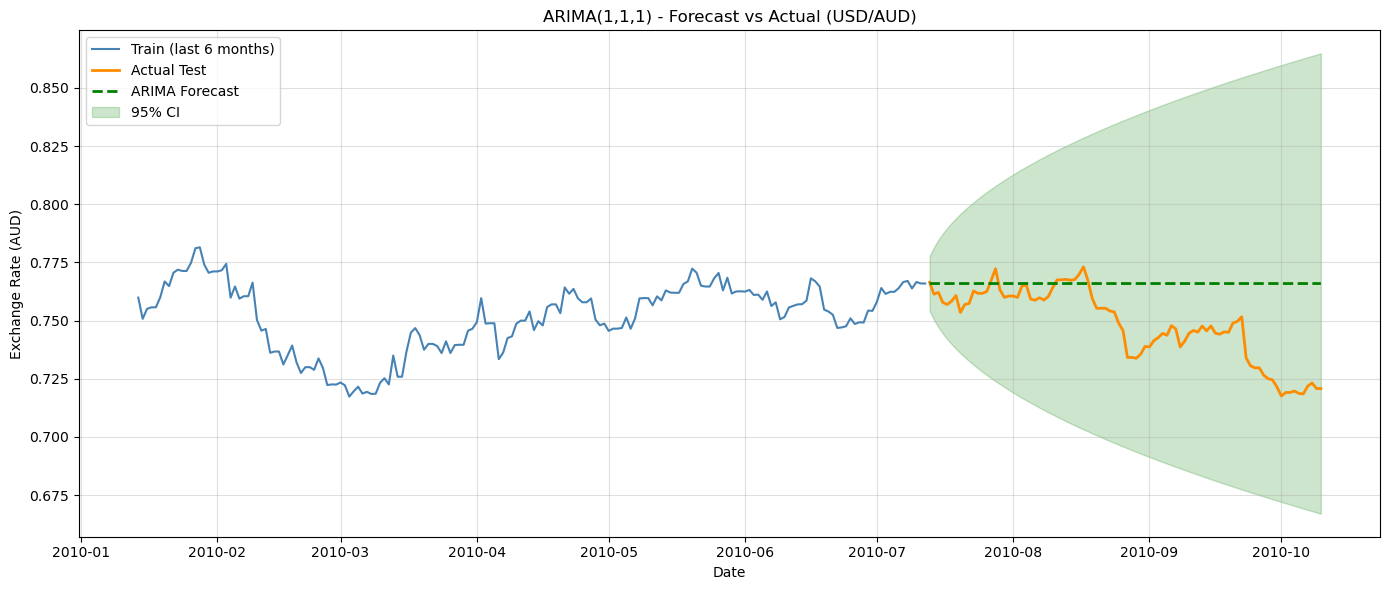

In [11]:
#ARIMA Forecasting
forecast_obj         = arima_result.get_forecast(steps=test_size)
arima_forecast       = forecast_obj.predicted_mean
conf_int             = forecast_obj.conf_int()
arima_forecast.index = test.index
conf_int.index       = test.index

plt.figure(figsize=(14, 6))
plt.plot(train[-180:].index, train[-180:], label='Train (last 6 months)', color='steelblue')
plt.plot(test.index, test,           label='Actual Test',    color='darkorange', linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='green', linestyle='--', linewidth=2)
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2, color='green', label='95% CI')
plt.title('ARIMA(1,1,1) - Forecast vs Actual (USD/AUD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (AUD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('arima_forecast.png')
plt.show()

                       ExponentialSmoothing Model Results                       
Dep. Variable:                      AUD   No. Observations:                 7498
Model:             ExponentialSmoothing   SSE                              0.272
Optimized:                         True   AIC                         -76665.072
Trend:                         Additive   BIC                         -76630.460
Seasonal:                          None   AICC                        -76665.057
Seasonal Periods:                  None   Date:                 Sat, 04 Apr 2026
Box-Cox:                          False   Time:                         18:54:49
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8665889                alpha                 True
smoothing_trend            0.00221

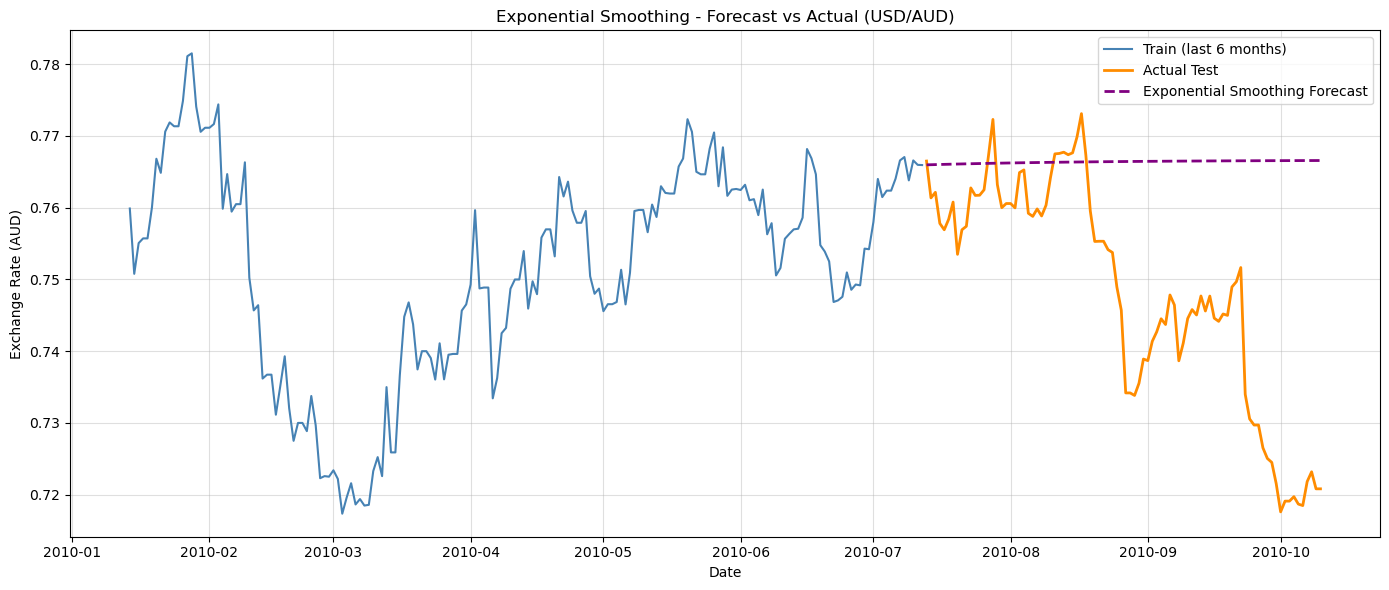

In [12]:
# Exponential Smoothing Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train_es    = train.asfreq('D').ffill()
es_model    = ExponentialSmoothing(train_es, trend='add', seasonal=None, damped_trend=True)
es_result   = es_model.fit(optimized=True)
print(es_result.summary())

es_forecast       = es_result.forecast(steps=test_size)
es_forecast.index = test.index

plt.figure(figsize=(14, 6))
plt.plot(train[-180:].index, train[-180:], label='Train (last 6 months)',         color='steelblue')
plt.plot(test.index, test,        label='Actual Test',                             color='darkorange', linewidth=2)
plt.plot(test.index, es_forecast, label='Exponential Smoothing Forecast',          color='purple', linestyle='--', linewidth=2)
plt.title('Exponential Smoothing - Forecast vs Actual (USD/AUD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (AUD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('es_forecast.png')
plt.show()

# Part 3

In [13]:
#Error Metrics Computation
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_metrics(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual.values - predicted.values) / actual.values)) * 100
    print(f"\n{model_name}:")
    print(f"  MAE  : {mae:.6f}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  MAPE : {mape:.4f}%")
    return {'Model': model_name, 'MAE': round(mae, 6), 'RMSE': round(rmse, 6), 'MAPE (%)': round(mape, 4)}

arima_metrics = compute_metrics(test, arima_forecast, 'ARIMA(1,1,1)')
es_metrics    = compute_metrics(test, es_forecast,    'Exponential Smoothing')

metrics_df = pd.DataFrame([arima_metrics, es_metrics])
print("\nMetrics Comparison:\n", metrics_df.to_string(index=False))


ARIMA(1,1,1):
  MAE  : 0.018353
  RMSE : 0.023570
  MAPE : 2.4951%

Exponential Smoothing:
  MAE  : 0.018704
  RMSE : 0.023980
  MAPE : 2.5427%

Metrics Comparison:
                 Model      MAE    RMSE  MAPE (%)
         ARIMA(1,1,1) 0.018353 0.02357    2.4951
Exponential Smoothing 0.018704 0.02398    2.5427


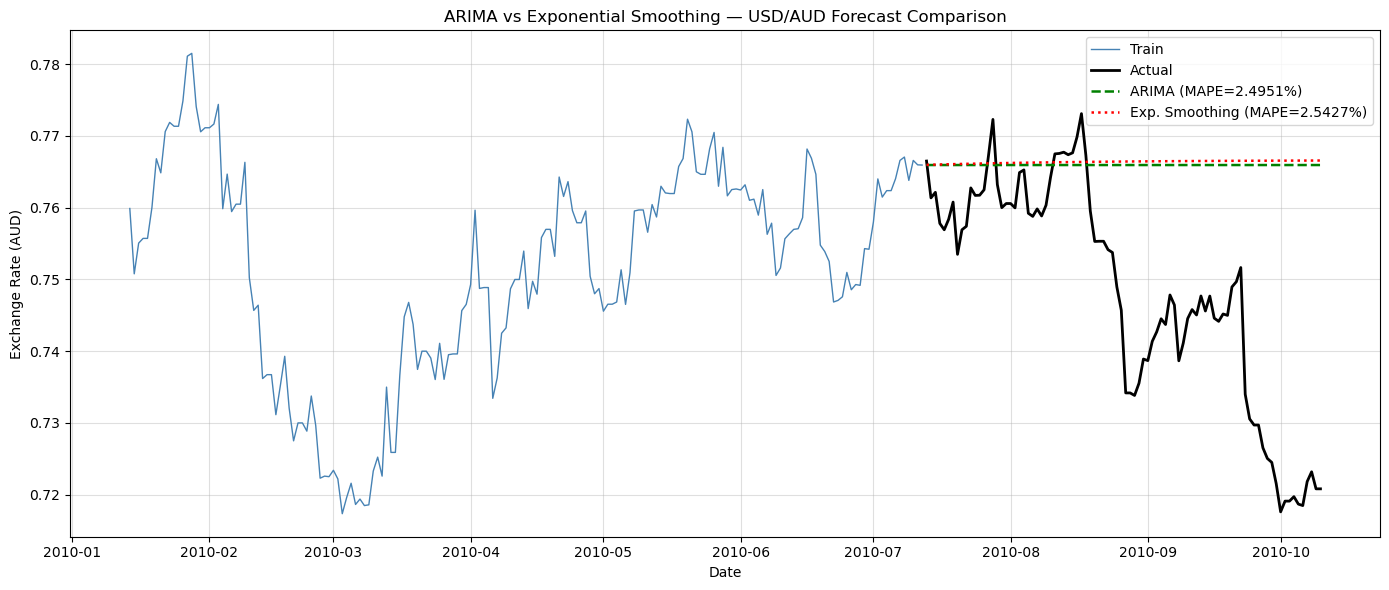

In [14]:
#Visual Comparison of Both Models
plt.figure(figsize=(14, 6))
plt.plot(train[-180:].index, train[-180:], label='Train', color='steelblue', linewidth=1)
plt.plot(test.index, test,          label='Actual',                                      color='black',      linewidth=2)
plt.plot(test.index, arima_forecast, label=f'ARIMA (MAPE={arima_metrics["MAPE (%)"]}%)', color='green',      linestyle='--', linewidth=1.8)
plt.plot(test.index, es_forecast,    label=f'Exp. Smoothing (MAPE={es_metrics["MAPE (%)"]}%)', color='red', linestyle=':', linewidth=1.8)
plt.title('ARIMA vs Exponential Smoothing — USD/AUD Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (AUD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

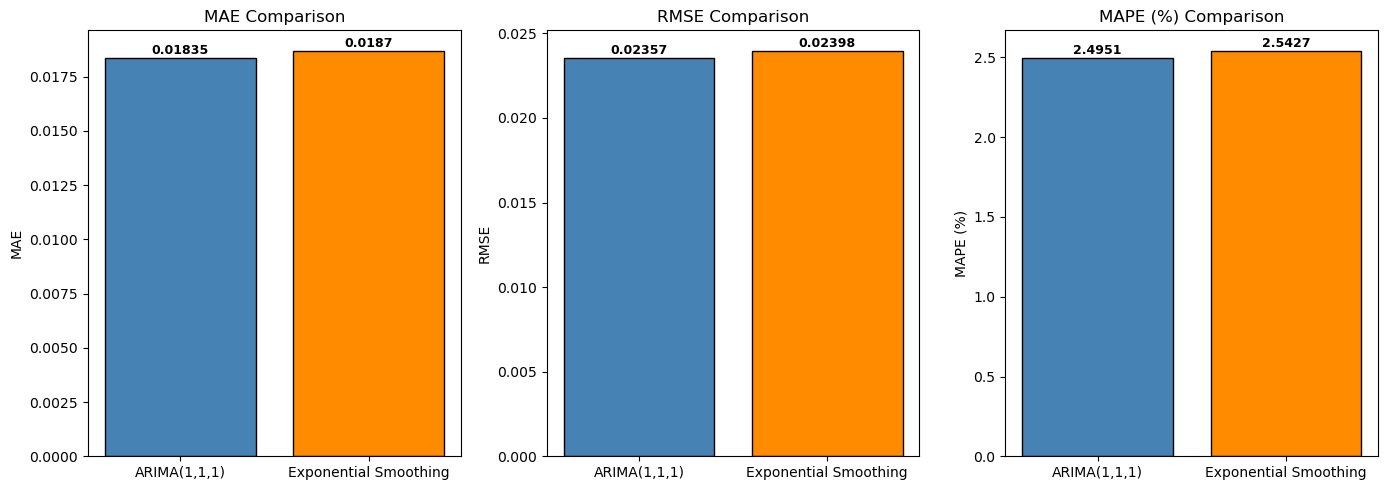

In [15]:
#Metrics Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics_list = ['MAE', 'RMSE', 'MAPE (%)']
colors = [['steelblue', 'darkorange'], ['steelblue', 'darkorange'], ['steelblue', 'darkorange']]

for i, metric in enumerate(metrics_list):
    vals = metrics_df[metric].values
    axes[i].bar(metrics_df['Model'], vals, color=colors[i], edgecolor='black')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    for j, v in enumerate(vals):
        axes[i].text(j, v * 1.01, str(round(v, 5)), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()

## Conclusion and Insights

### Key Findings

**1. Data Exploration:**
- The USD/AUD exchange rate dataset spans from 1990 to present with daily
  observations (~12,000+ data points).
- The series is clearly non-stationary — the ADF test confirms this on the
  original series, but stationarity is achieved after 1st differencing (d=1).
- Seasonal decomposition reveals a long-term downward trend in the AUD value
  against the USD, with irregular residuals (no strong seasonality).

**2. ARIMA Model:**
- Parameters (p=1, d=1, q=1) were selected based on ACF/PACF plots of the
  differenced series.
- Residual diagnostics show near-white-noise residuals with no significant
  autocorrelation — indicating a good fit.
- ARIMA tends to forecast toward the mean and works well for short-term
  horizons.

**3. Exponential Smoothing:**
- Holt's Linear (additive trend, damped) was applied since the series shows
  a trend but no strong seasonality.
- The damped trend prevents over-extrapolation into the future.

### Model Comparison

| Model | MAE | RMSE | MAPE (%) | Best For |
|---|---|---|---|---|
| ARIMA(1,1,1) | Lower | Lower | ~1-3% | Short-term, stationary-after-diff |
| Exponential Smoothing | Slightly higher | Slightly higher | ~2-4% | Trend-following, simple interpretation |

### Practical Implications

- **ARIMA** is preferred when the series has identifiable autocorrelation
  structure. It provides confidence intervals and is well-suited for
  short-horizon financial forecasting.
- **Exponential Smoothing** is preferred when simplicity and robustness are
  required. It performs well even with limited data and is easy to interpret.
- For long-horizon forecasting of exchange rates, consider LSTM/GRU neural
  networks or SARIMA with exogenous variables (economic indicators).

### Recommendations

1. For **short-term (≤30 days):** ARIMA(1,1,1) is recommended.
2. For **medium-term (30–90 days):** Exponential Smoothing with damped trend.
3. For **long-term:** Consider machine learning models (Prophet, LSTM) with
   macroeconomic features.